In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import utils.UVA as UVA
import utils.MVA as MVA
import utils.PCA as PCA

from sklearn.preprocessing import OneHotEncoder, StandardScaler, StandardScaler
#from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, DBSCAN
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, silhouette_samples

#from yellowbrick.cluster import KElbowVisualizer

In [2]:
# pip install threadpoolctl==3.1.0

In [3]:
#import warnings
#warnings.filterwarnings("ignore")

In [4]:
pwd

'\\\\wsl.localhost\\Ubuntu\\home\\dgaillot\\code\\openclassrooms\\openclassrooms\\projets\\projet_5'

In [5]:
#df = pd.read_csv('data/olist_rfm.csv')

df = pd.read_csv('data/clean_df_customers.csv')

In [6]:
df.head()

,recency,computers_accessories,garden_tools,health_beauty,housewares,watches_gifts,other_categories,freight_value,frequency_light,frequency_medium,frequency_heavy,sellers_count,mean_pay_installments,electronics
0,380,0.0,0.0,0.0,29.99,0.0,35.39,17.44,1,1,0,2,1.0,0.0
1,85,0.0,0.0,0.0,0.00,0.0,118.70,22.76,1,0,0,1,1.0,0.0
2,70,0.0,0.0,0.0,0.00,0.0,159.90,19.22,0,1,0,1,3.0,0.0
3,333,0.0,0.0,0.0,0.00,0.0,45.00,27.20,0,1,0,1,1.0,0.0
4,246,0.0,0.0,0.0,0.00,0.0,19.90,8.72,1,0,0,1,1.0,0.0


In [7]:
# remove customer_unique_id
#df.drop(['customer_unique_id'], axis=1, inplace=True)
#df.head()

In [8]:
df.shape

(95399, 14)

In [9]:
df.dtypes

recency                    int64
computers_accessories    float64
garden_tools             float64
health_beauty            float64
housewares               float64
watches_gifts            float64
other_categories         float64
freight_value            float64
frequency_light            int64
frequency_medium           int64
frequency_heavy            int64
sellers_count              int64
mean_pay_installments    float64
electronics              float64
dtype: object

In [10]:
df.isna().sum()

recency                  0
computers_accessories    0
garden_tools             0
health_beauty            0
housewares               0
watches_gifts            0
other_categories         0
freight_value            0
frequency_light          0
frequency_medium         0
frequency_heavy          0
sellers_count            0
mean_pay_installments    0
electronics              0
dtype: int64

In [11]:
quantiles = df.quantile(q=[0.25,0.5,0.75])
quantiles

,recency,computers_accessories,garden_tools,health_beauty,housewares,watches_gifts,other_categories,freight_value,frequency_light,frequency_medium,frequency_heavy,sellers_count,mean_pay_installments,electronics
0.25,163.0,0.0,0.0,0.0,0.0,0.0,0.0,14.08,0.0,0.0,0.0,1.0,1.0,0.0
0.50,268.0,0.0,0.0,0.0,0.0,0.0,29.9,17.60,0.0,0.0,0.0,1.0,2.0,0.0
0.75,397.0,0.0,0.0,0.0,0.0,0.0,99.9,25.54,1.0,1.0,1.0,1.0,4.0,0.0


# Distribution

In [12]:
num_cols = df.select_dtypes(include=np.number).columns.to_list()
num_cols

['recency',
 'computers_accessories',
 'garden_tools',
 'health_beauty',
 'housewares',
 'watches_gifts',
 'other_categories',
 'freight_value',
 'frequency_light',
 'frequency_medium',
 'frequency_heavy',
 'sellers_count',
 'mean_pay_installments',
 'electronics']

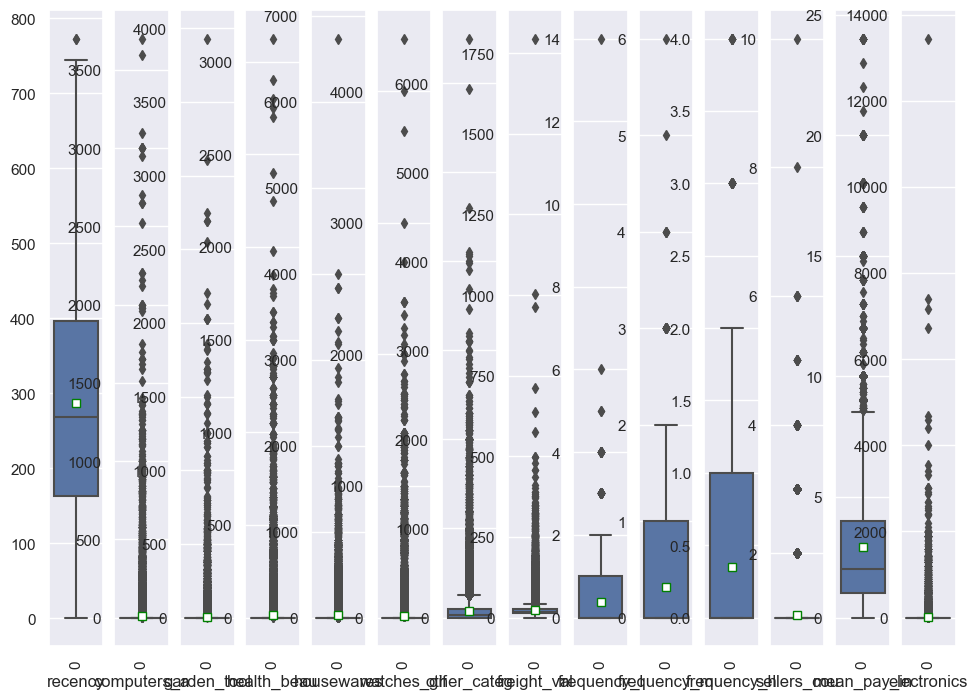

In [13]:
MVA.boxplot_nums(df, num_cols)

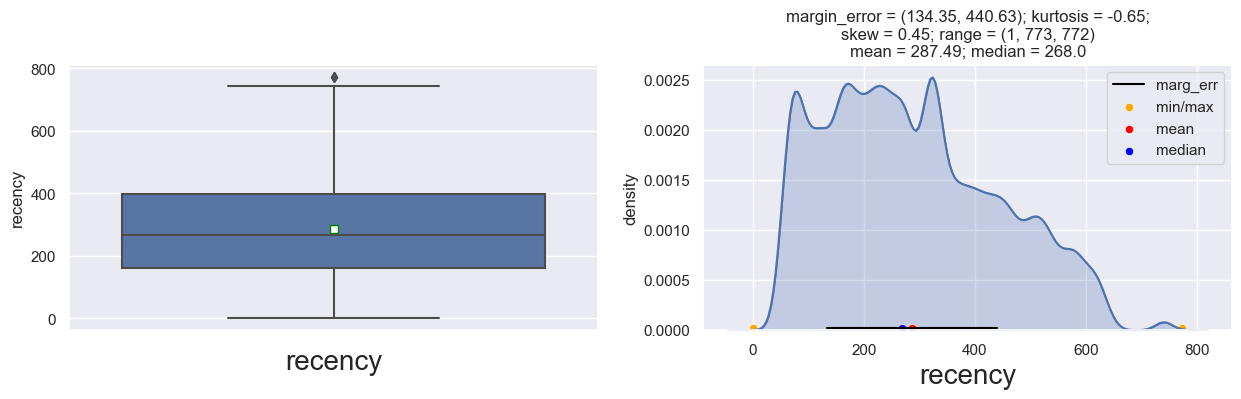

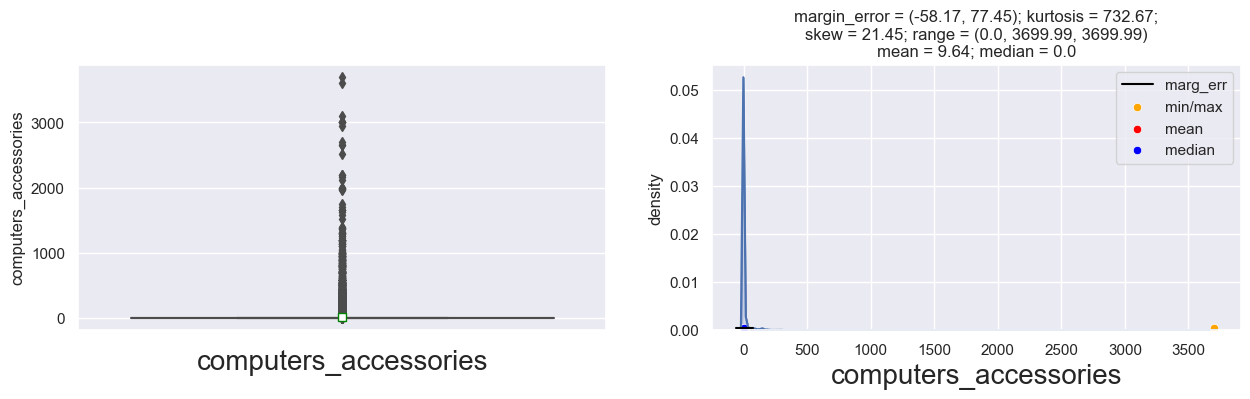

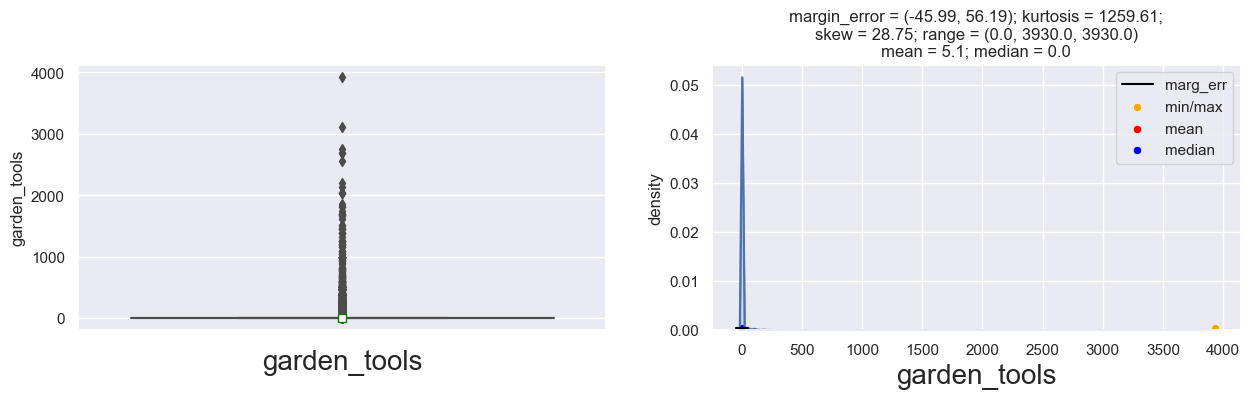

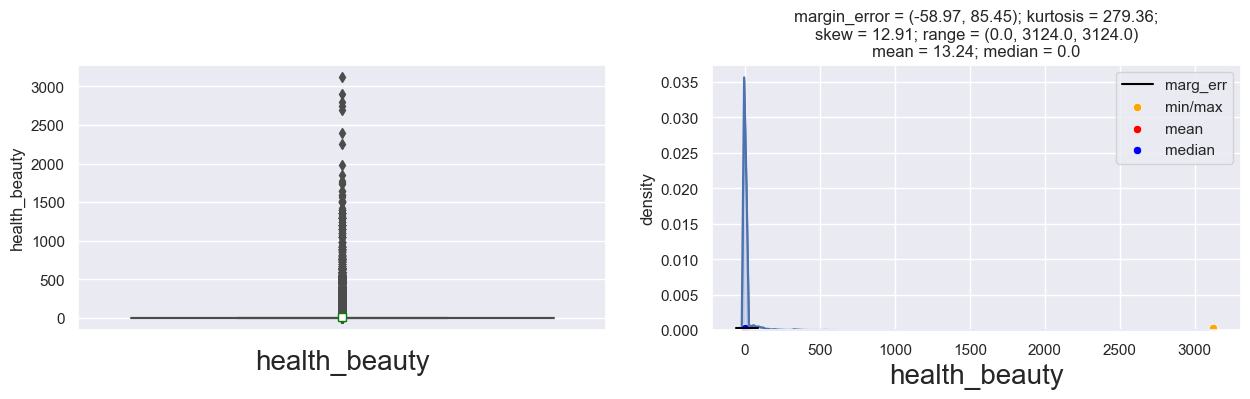

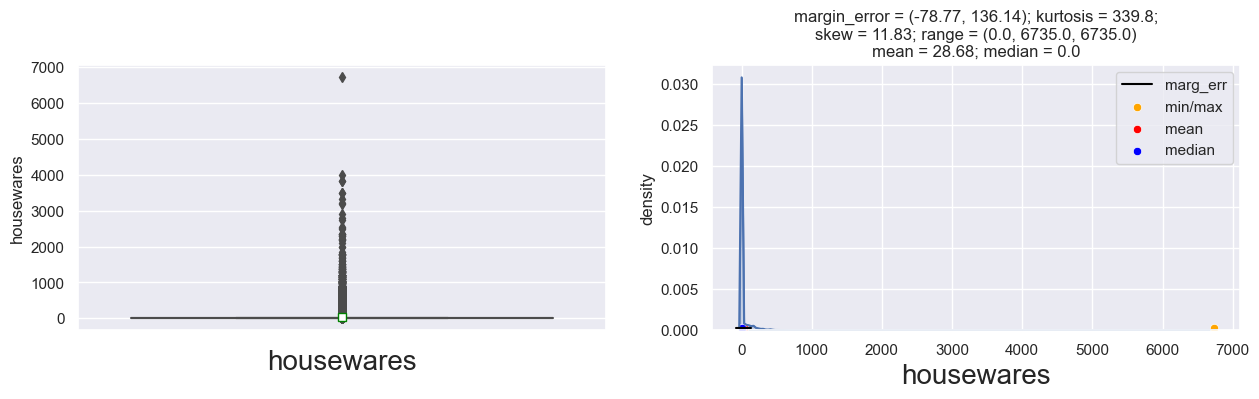

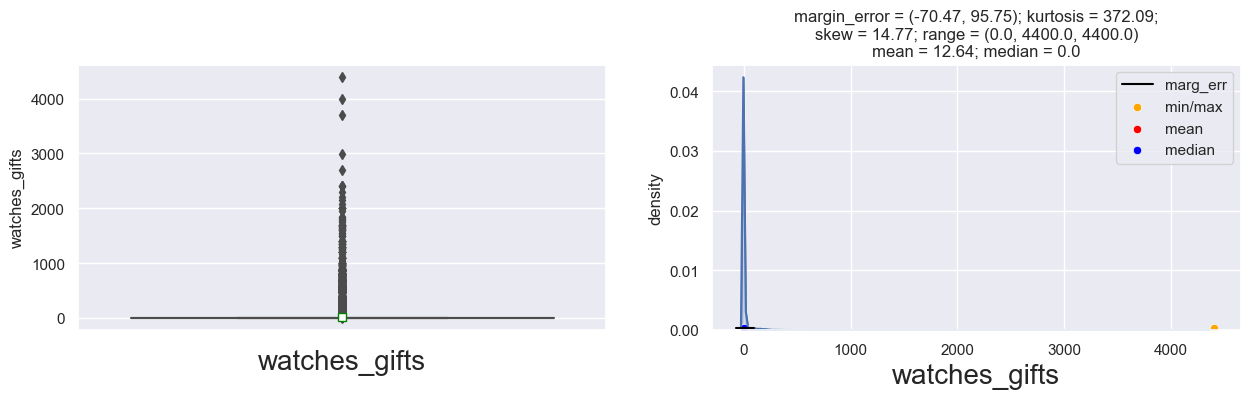

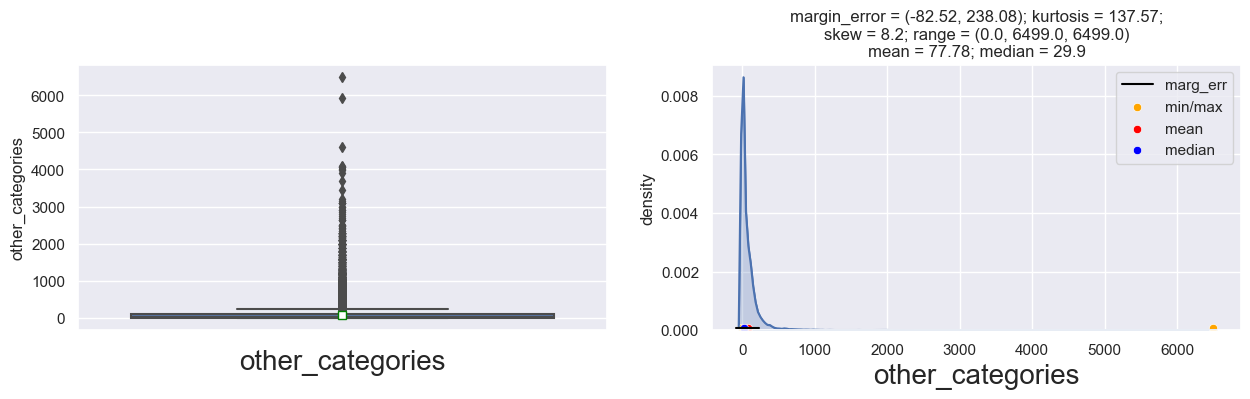

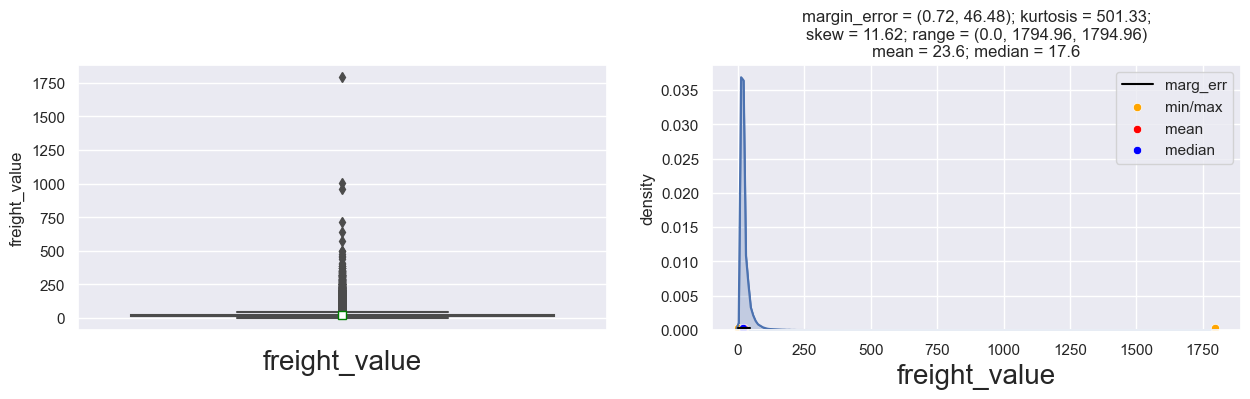

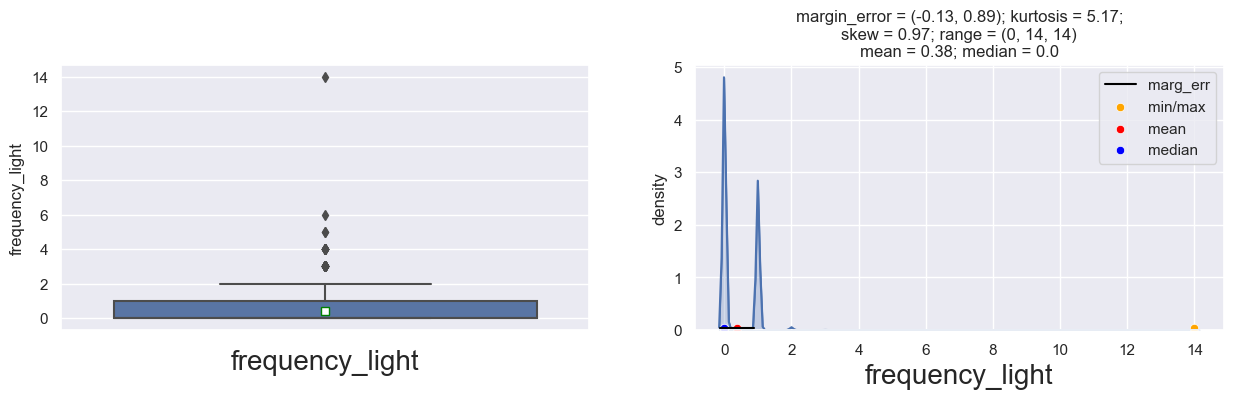

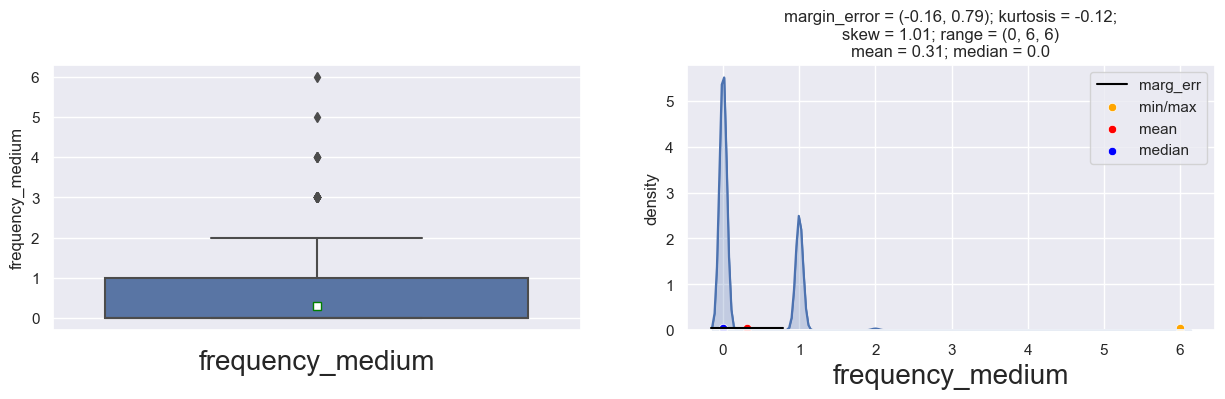

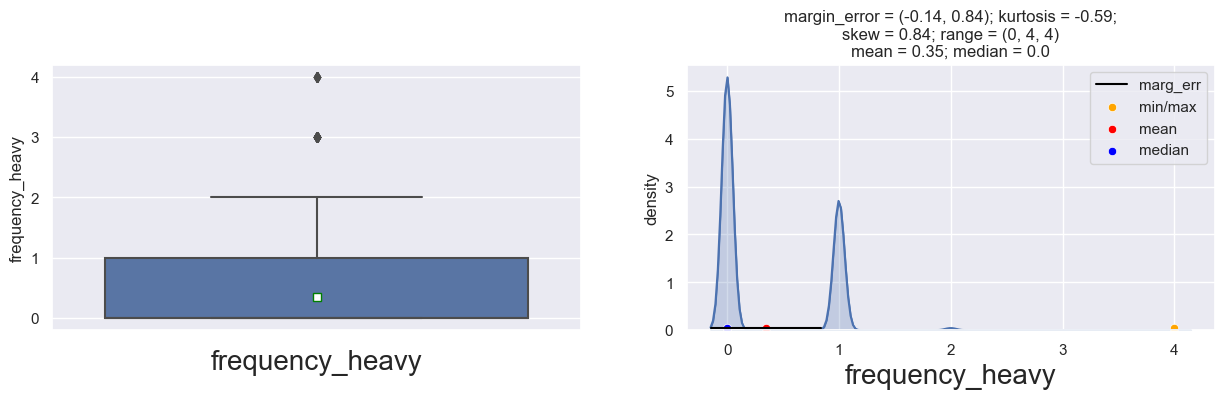

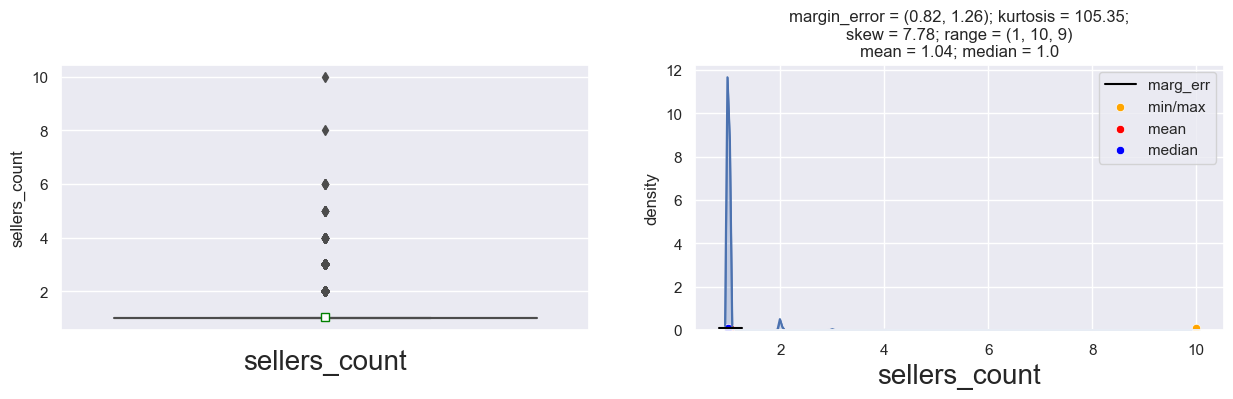

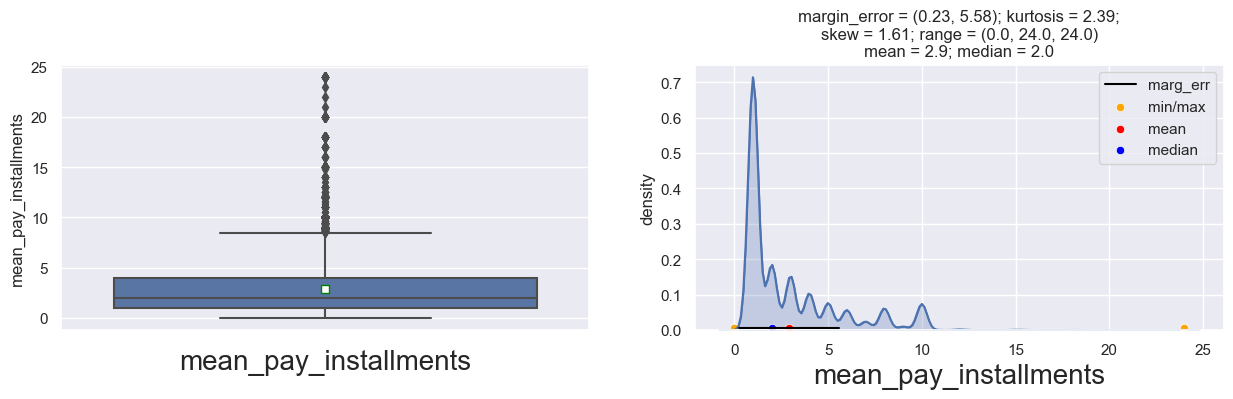

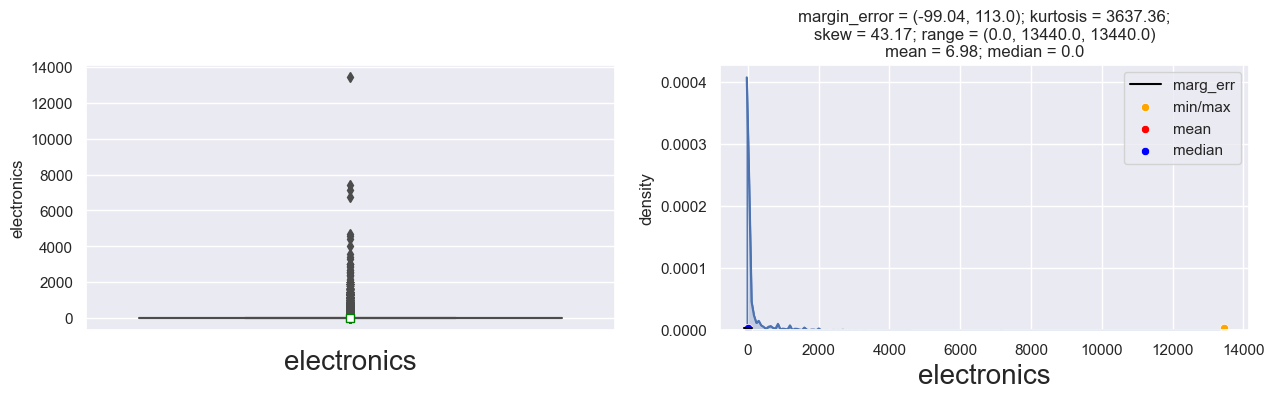

In [14]:
UVA.num_plus(df, num_cols)

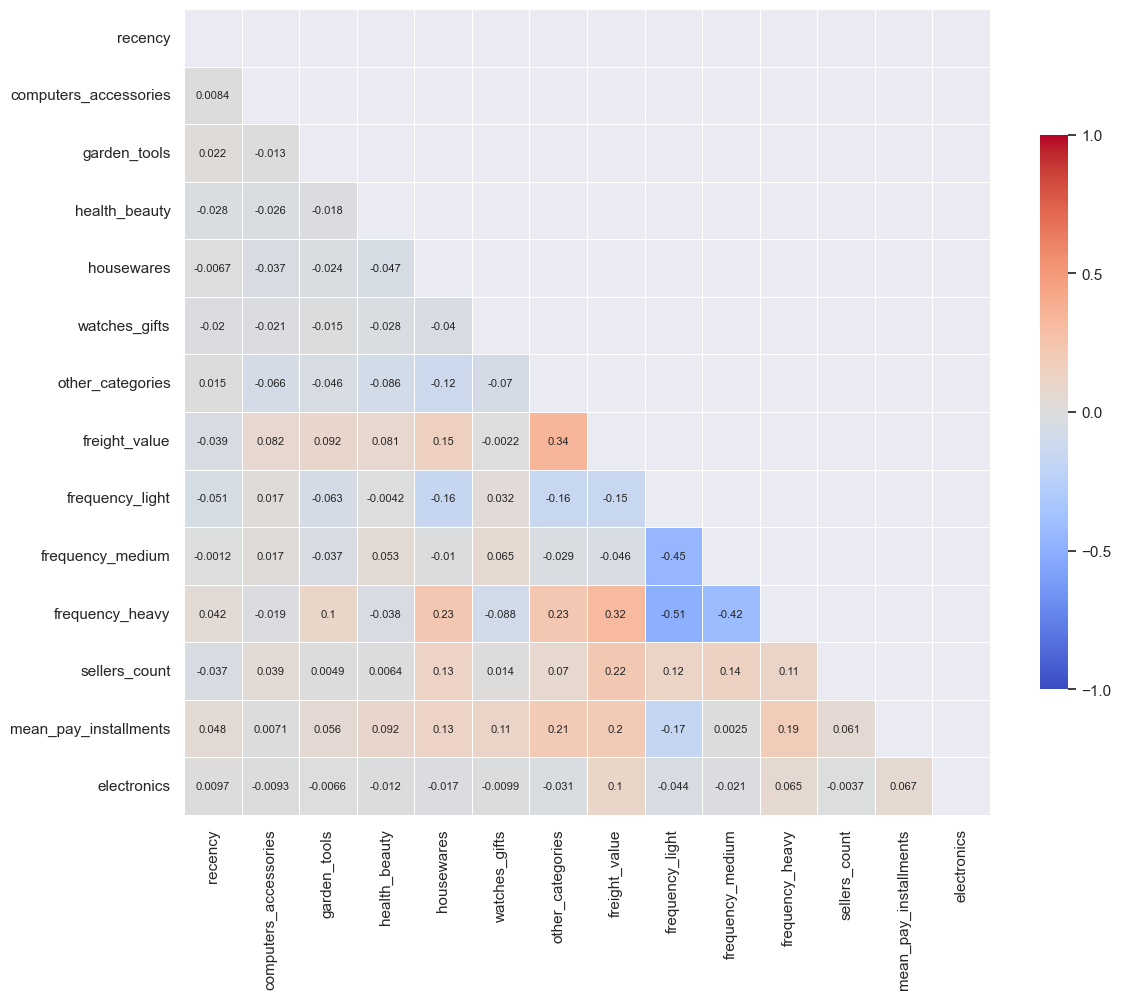

In [15]:
MVA.heatmap_num_2(df, annot_val=True, textsize=8) #

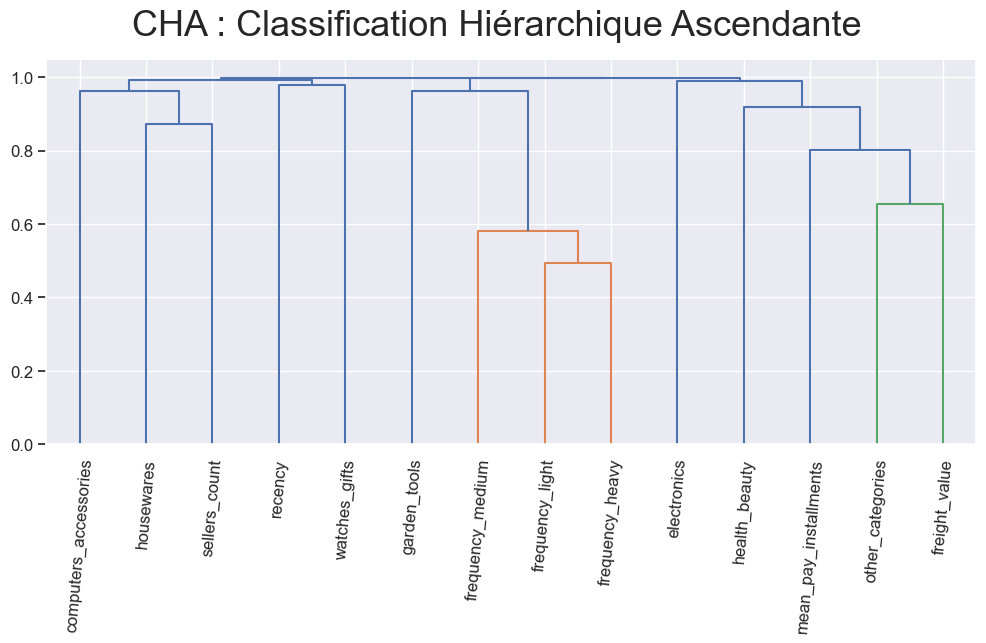

In [16]:
PCA.CHA(df, num_cols, label_size=12, rotation=85)

# Echantillon

In [17]:
df_redux = df.sample(10000, random_state=1).copy()
X = df_redux.copy()
#categorical_columns = X.select_dtypes(['category','object']).columns
num_cols = X.select_dtypes(include=np.number).columns.to_list()

ss = StandardScaler()
X[num_cols] = ss.fit_transform(X[num_cols])

### X_std / echantillon

In [18]:
X_std = PCA.clean_data(df, num_cols, impute=False, std=True)

	>>> Selected features: ['recency', 'computers_accessories', 'garden_tools', 'health_beauty', 'housewares', 'watches_gifts', 'other_categories', 'freight_value', 'frequency_light', 'frequency_medium', 'frequency_heavy', 'sellers_count', 'mean_pay_installments', 'electronics']
	>>> Standardized data


In [19]:
X_std

,recency,computers_accessories,garden_tools,health_beauty,housewares,watches_gifts,other_categories,freight_value,frequency_light,frequency_medium,frequency_heavy,sellers_count,mean_pay_installments,electronics
0,0.604081,-0.142170,-0.099809,-0.183339,0.012155,-0.152115,-0.264431,-0.269261,1.220451,1.440315,-0.711205,4.432184,-0.710769,-0.065818
1,-1.322254,-0.142170,-0.099809,-0.183339,-0.266947,-0.152115,0.255284,-0.036748,1.220451,-0.658266,-0.711205,-0.175118,-0.710769,-0.065818
2,-1.420203,-0.142170,-0.099809,-0.183339,-0.266947,-0.152115,0.512303,-0.191465,-0.752066,1.440315,-0.711205,-0.175118,0.036052,-0.065818
3,0.297174,-0.142170,-0.099809,-0.183339,-0.266947,-0.152115,-0.204481,0.157305,-0.752066,1.440315,-0.711205,-0.175118,-0.710769,-0.065818
4,-0.270932,-0.142170,-0.099809,-0.183339,-0.266947,-0.152115,-0.361063,-0.650373,1.220451,-0.658266,-0.711205,-0.175118,-0.710769,-0.065818
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95394,1.955780,-0.142170,-0.099809,0.813732,-0.266947,-0.152115,-0.485206,-0.459817,-0.752066,1.440315,-0.711205,-0.175118,0.036052,-0.065818
95395,-0.225222,-0.142170,-0.099809,-0.183339,-0.266947,-0.152115,0.605878,-0.153005,-0.752066,-0.658266,1.324691,-0.175118,0.036052,-0.065818
95396,0.839159,-0.142170,-0.099809,-0.183339,-0.266947,-0.152115,0.799828,1.810248,-0.752066,-0.658266,1.324691,-0.175118,0.782873,-0.065818
95397,-0.035854,5.166825,-0.099809,-0.183339,-0.266947,-0.152115,-0.485206,2.516530,-0.752066,-0.658266,1.324691,-0.175118,0.409463,-0.065818


# PCA

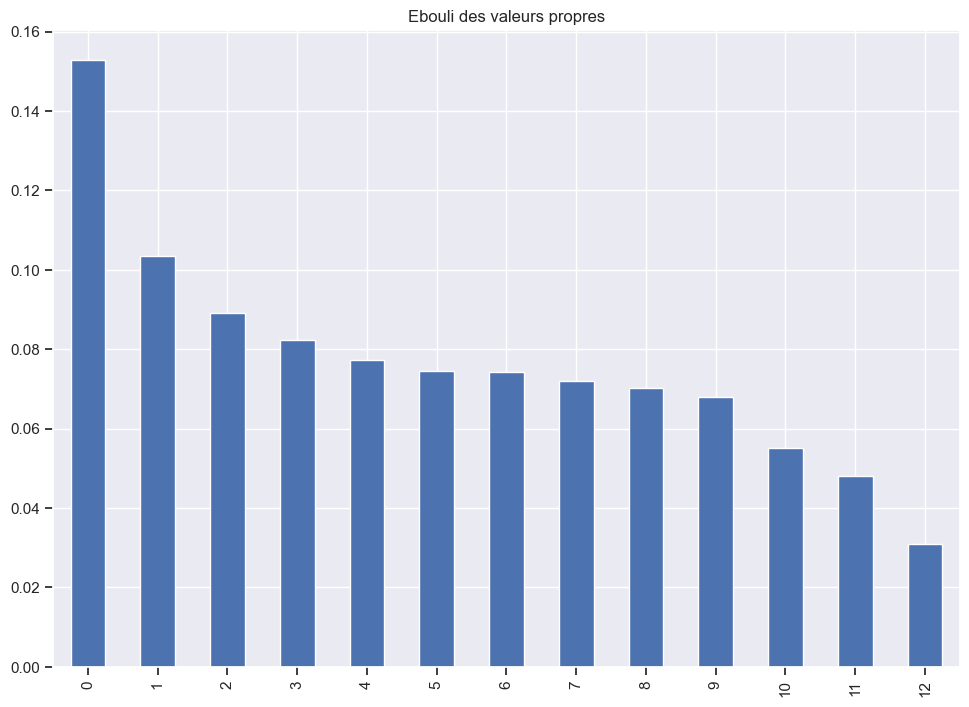

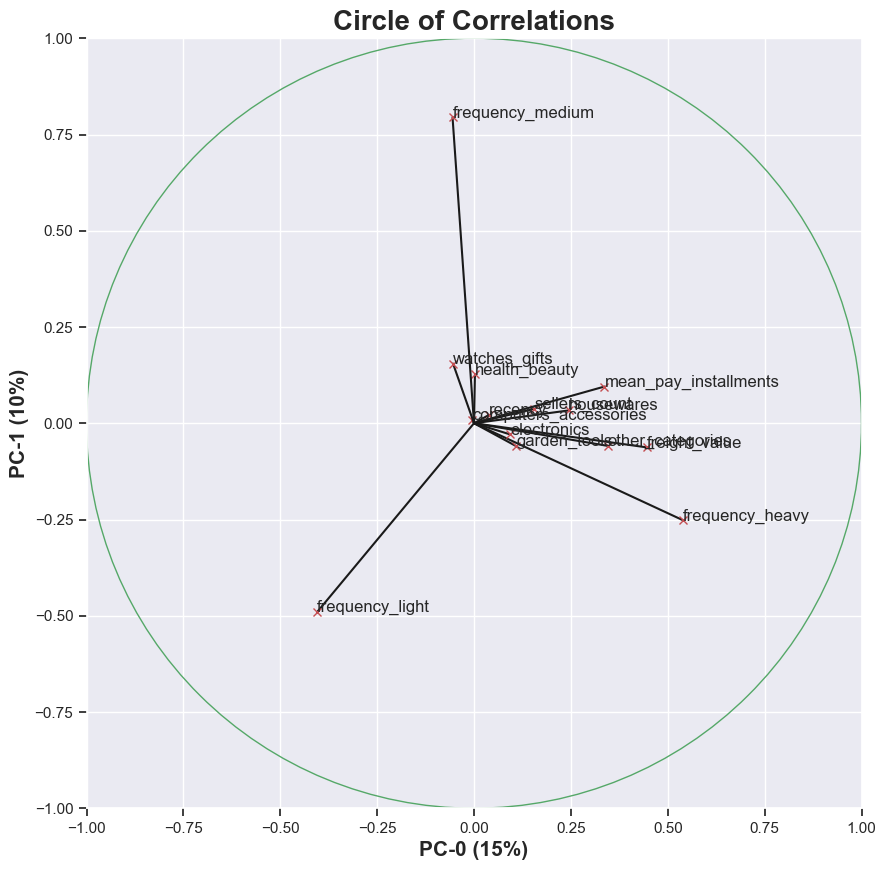

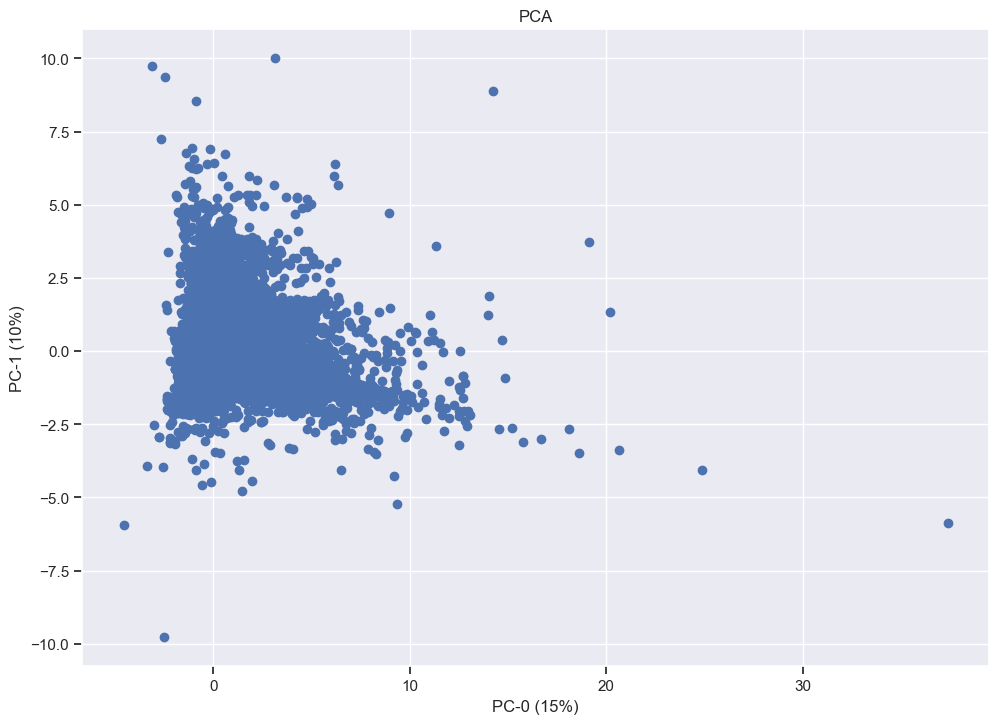

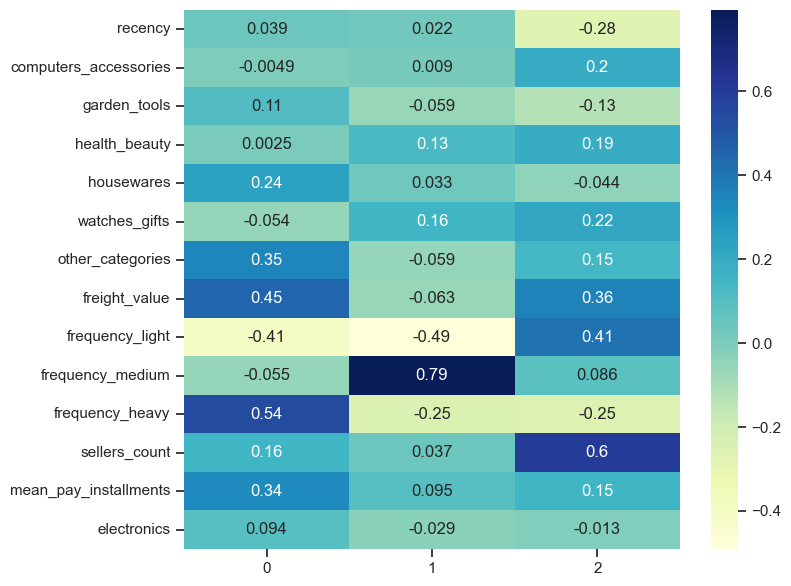

Résumé PCA
Total: 13 composants
----------------------------------------
Moyenne de la variance expliquée : 0.077
----------------------------------------
    explained variance  cumulative
1             0.152780    0.152780
2             0.103483    0.256263
3             0.089191    0.345454
4             0.082301    0.427755
5             0.077382    0.505137
6             0.074520    0.579657
7             0.074155    0.653812
8             0.071897    0.725709
9             0.070128    0.795838
10            0.068042    0.863880
11            0.055025    0.918905
12            0.048040    0.966945
13            0.030897    0.997842
----------------------------------------


,PC-0,PC-1,PC-2,PC-3,PC-4,PC-5,PC-6,PC-7,PC-8,PC-9,PC-10,PC-11,PC-12
recency,0.038974,0.021785,-0.278081,-0.121418,0.081140,-0.018831,0.438835,-0.016633,-0.648701,0.489092,0.169651,0.131050,0.012462
computers_accessories,-0.004935,0.008957,0.199796,0.098515,-0.214471,0.386599,0.616858,0.085419,-0.163333,-0.548153,-0.039939,-0.044127,-0.190561
garden_tools,0.108453,-0.059237,-0.128271,0.056756,0.241848,0.264600,0.308901,-0.647882,0.450738,0.238631,-0.136393,0.065402,-0.195930
health_beauty,0.002485,0.127090,0.193734,-0.013377,0.380467,0.581418,-0.467220,-0.112267,-0.332600,-0.041285,0.234155,0.003874,-0.255429
housewares,0.244564,0.033340,-0.043784,0.701102,0.002954,-0.213050,-0.111730,0.070221,-0.156018,0.007907,-0.251070,0.388180,-0.380271
watches_gifts,-0.054162,0.155083,0.223311,-0.058164,0.547080,-0.515720,0.224148,-0.043395,0.083236,-0.264469,0.434869,0.093218,-0.166425
other_categories,0.345401,-0.058826,0.145304,-0.600252,-0.285538,-0.166604,-0.094261,-0.021950,-0.015649,0.034512,-0.110445,0.117676,-0.591263
freight_value,0.447215,-0.062853,0.361134,-0.074117,-0.043357,0.144645,0.033029,-0.000832,0.076845,0.014330,0.147316,0.600495,0.497527
frequency_light,-0.405173,-0.490797,0.408115,-0.001517,0.078799,-0.046282,0.027440,-0.019480,-0.092434,0.157065,-0.186795,0.132999,-0.051111
frequency_medium,-0.055396,0.794653,0.086436,-0.019700,-0.160202,0.025765,0.037707,-0.008073,0.087425,0.133131,-0.064660,0.055904,0.013969


In [20]:
PCA.myPCA(X_std)

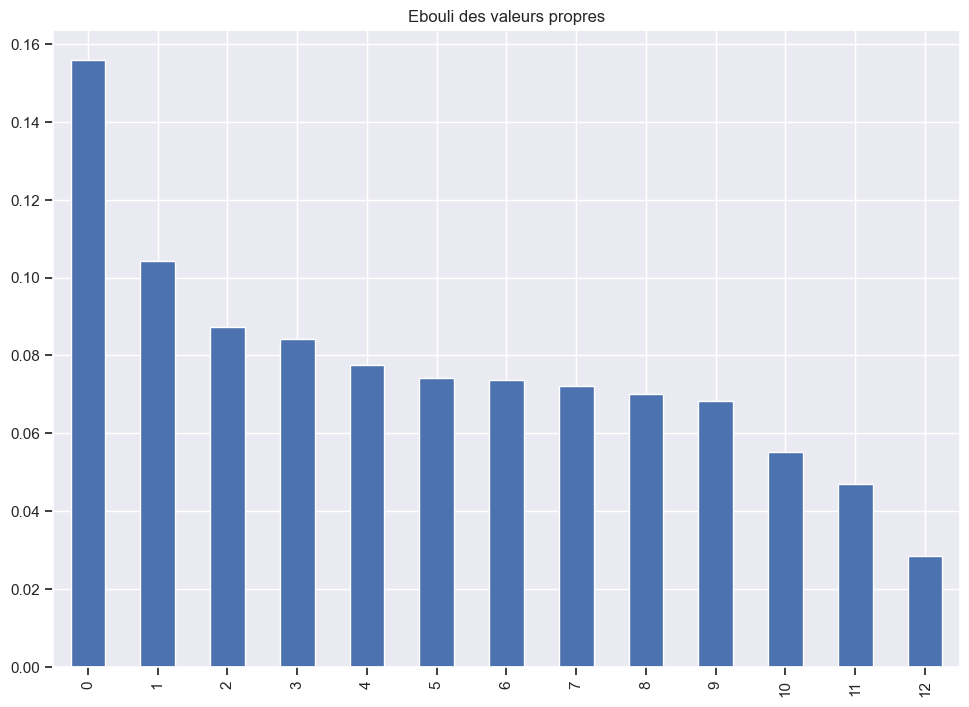

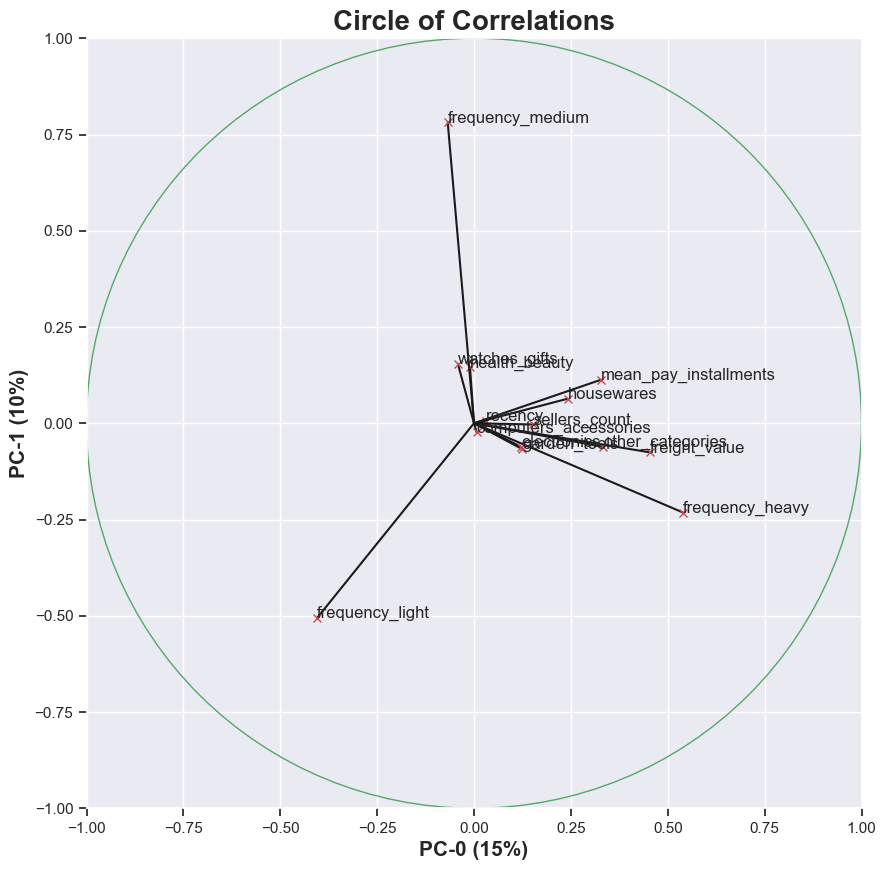

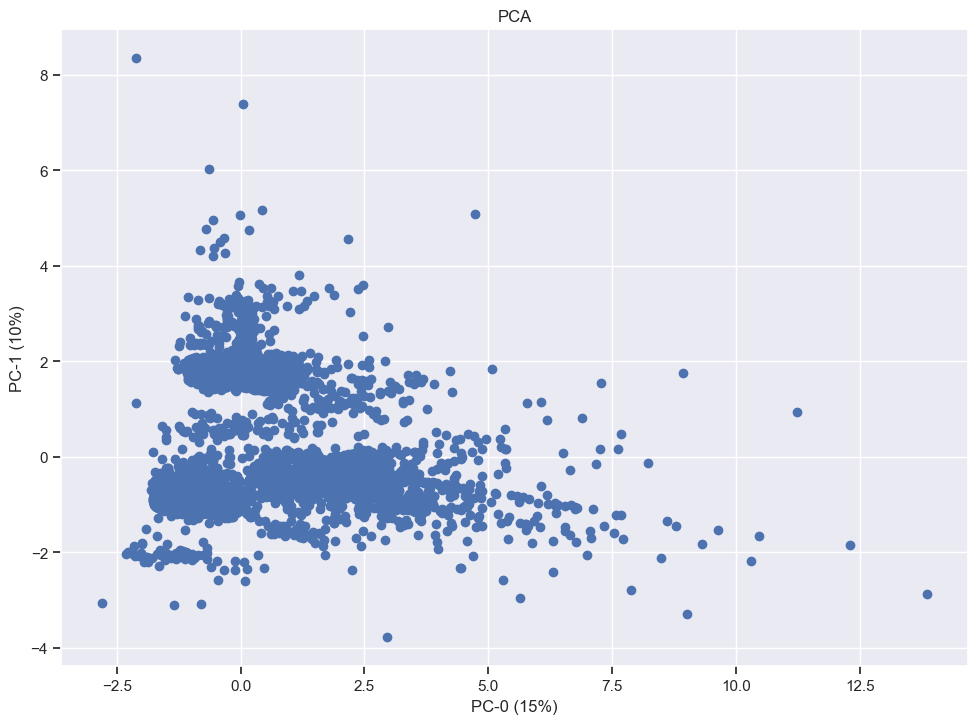

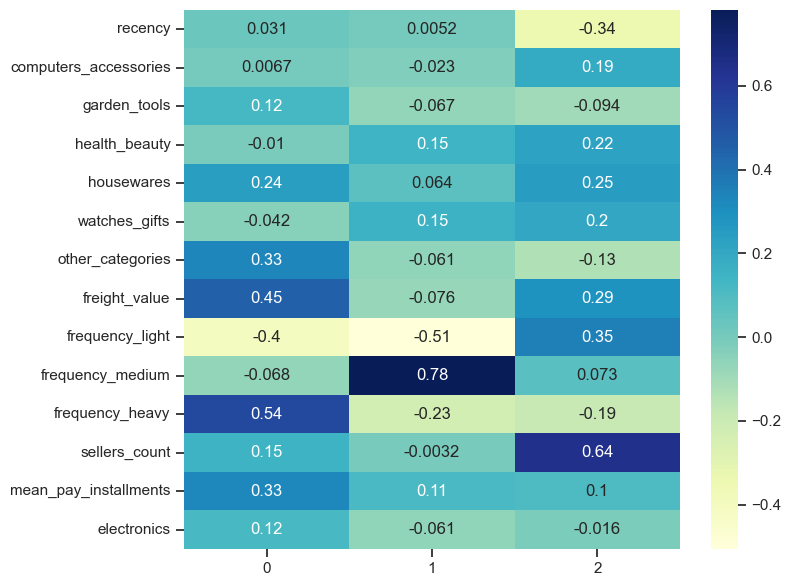

Résumé PCA
Total: 13 composants
----------------------------------------
Moyenne de la variance expliquée : 0.077
----------------------------------------
    explained variance  cumulative
1             0.155833    0.155833
2             0.104179    0.260012
3             0.087434    0.347446
4             0.084348    0.431794
5             0.077592    0.509386
6             0.074096    0.583483
7             0.073581    0.657064
8             0.072206    0.729270
9             0.070049    0.799319
10            0.068259    0.867579
11            0.055107    0.922686
12            0.046902    0.969588
13            0.028440    0.998027
----------------------------------------


,PC-0,PC-1,PC-2,PC-3,PC-4,PC-5,PC-6,PC-7,PC-8,PC-9,PC-10,PC-11,PC-12
recency,0.030634,0.005216,-0.340120,-0.097704,0.082588,0.385016,0.007538,0.165825,-0.652884,0.441401,0.230650,0.124551,-0.037239
computers_accessories,0.006672,-0.023458,0.191421,0.042275,0.122162,0.639445,-0.503806,-0.293948,-0.060348,-0.381700,0.037388,-0.051035,0.208795
garden_tools,0.124053,-0.067015,-0.093735,-0.140562,0.299246,0.242816,-0.175070,0.651027,0.482088,0.190261,-0.181255,0.052292,0.210681
health_beauty,-0.010372,0.145350,0.223623,0.111676,0.355784,-0.537891,-0.434287,0.262249,-0.321815,-0.102253,0.275795,0.031513,0.227855
housewares,0.242002,0.063791,0.249571,-0.629941,-0.065194,-0.059291,0.209614,-0.072933,-0.195097,-0.123679,-0.238587,0.407348,0.380785
watches_gifts,-0.041554,0.154176,0.204441,0.201831,0.393590,0.218856,0.658333,0.080964,0.071045,-0.207722,0.416995,0.020411,0.163414
other_categories,0.333675,-0.061125,-0.133198,0.582808,-0.394192,-0.012974,0.058765,0.039326,-0.051373,0.058593,-0.079376,0.104746,0.586165
freight_value,0.454350,-0.075654,0.290349,0.220811,-0.004806,0.054009,-0.112265,0.002337,0.108741,0.066446,0.155821,0.595556,-0.493638
frequency_light,-0.404764,-0.505627,0.349125,0.141216,0.022005,0.032336,0.064607,0.078912,-0.130381,0.138509,-0.181815,0.146190,0.049541
frequency_medium,-0.067846,0.781307,0.072724,0.043961,-0.140389,0.088258,-0.081983,-0.020229,0.099933,0.181422,-0.056225,0.057671,-0.012385


In [21]:
PCA.myPCA(X)

In [22]:
#MVA.heatmap_num_2(X_enc)

In [23]:
#num_cols_Xenc = X_enc.select_dtypes(include=np.number).columns.to_list()

In [24]:
#PCA.CHA(X_enc, num_cols_Xenc)

# K-Means

In [25]:
# print avancement au fur et à mesure

### Elbow method

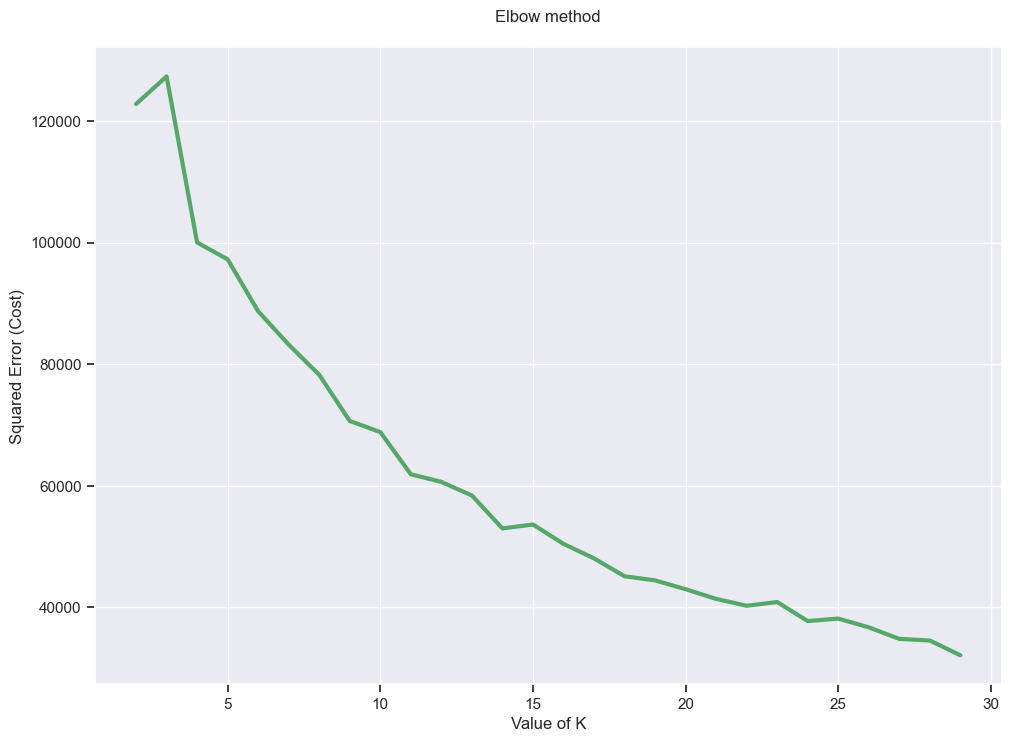

In [26]:
cost =[]
test_clusters = [i for i in range(2, 30)]
for i in test_clusters:
    #cls=KMeans(n_clusters=i,n_init=50,init='k-means++')
    cls = KMeans(n_clusters=i)
    cls.fit(X)
    cost.append(cls.inertia_)    


plt.plot(test_clusters, cost, color ='g', linewidth ='3')
plt.title("Elbow method\n")
plt.xlabel("Value of K")
plt.ylabel("Squared Error (Cost)")
#plt.axvline(x=nb_groupes_de_points, ymin=0, ymax=1, color="red")
plt.show()

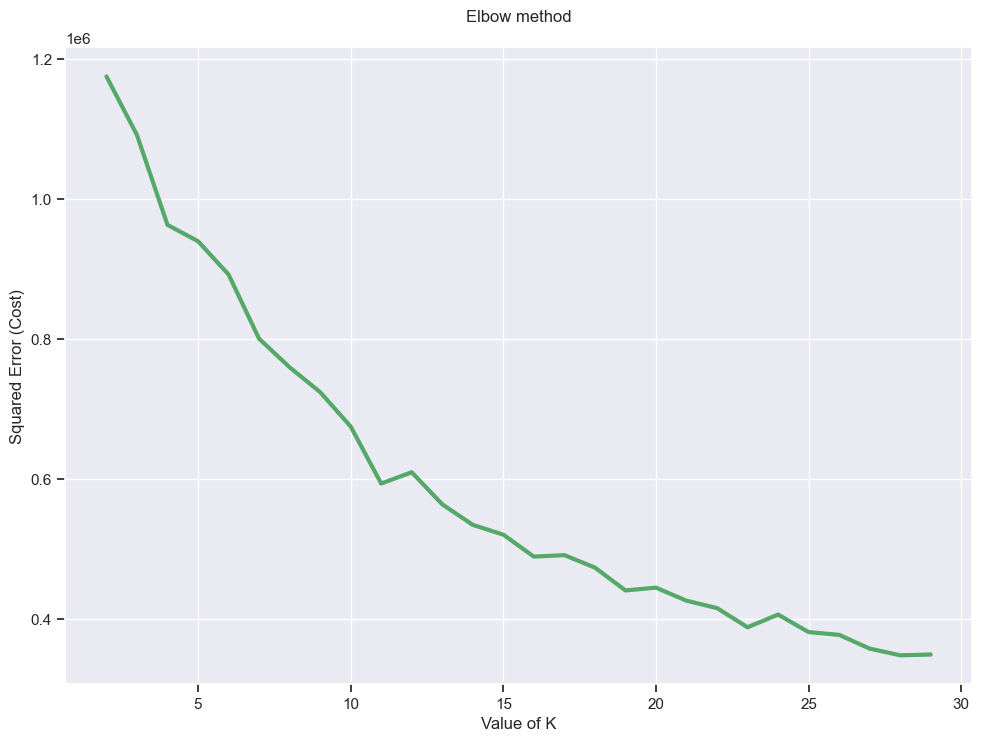

In [27]:
cost =[]
test_clusters = [i for i in range(2, 30)]
for i in test_clusters:
    #cls=KMeans(n_clusters=i,n_init=50,init='k-means++')
    cls = KMeans(n_clusters=i)
    cls.fit(X_std)
    cost.append(cls.inertia_)    


plt.plot(test_clusters, cost, color ='g', linewidth ='3')
plt.title("Elbow method\n")
plt.xlabel("Value of K")
plt.ylabel("Squared Error (Cost)")
#plt.axvline(x=nb_groupes_de_points, ymin=0, ymax=1, color="red")
plt.show()

In [28]:
# recherche nb optimum de clusters
## inertia = Sum of squared distances of samples to their closest cluster center

In [29]:
inertia = {}
dict_kmeans = {}
for k in range(1,25):
    print(k)
    kmeans = KMeans(n_clusters=k,
                   verbose=1,
                   random_state=0
                   ).fit(X_std)
    inertia[k] = kmeans.inertia_
    dict_kmeans[k] = kmeans

1
Initialization complete
Iteration 0, inertia 1698798.8586185146.
Iteration 1, inertia 1335585.9999999953.
Converged at iteration 1: strict convergence.
2
Initialization complete
Iteration 0, inertia 1499499.8234178792.
Iteration 1, inertia 1182986.583863979.
Iteration 2, inertia 1175195.7661316004.
Iteration 3, inertia 1174884.9480633333.
Iteration 4, inertia 1174879.0480592058.
Converged at iteration 4: center shift 2.7319680386771213e-06 within tolerance 0.00010000000000000478.
3
Initialization complete
Iteration 0, inertia 1274651.5556744894.
Iteration 1, inertia 1052565.5897091487.
Iteration 2, inertia 1042313.8243609049.
Iteration 3, inertia 1042185.6982848214.
Iteration 4, inertia 1042176.6114687118.
Converged at iteration 4: center shift 2.548876816452081e-05 within tolerance 0.00010000000000000478.
4
Initialization complete
Iteration 0, inertia 1225064.1229090872.
Iteration 1, inertia 1022211.0328912231.
Iteration 2, inertia 1002388.6958818443.
Iteration 3, inertia 997711.114

<AxesSubplot:title={'center':'Kmeans : Comparaison de la somme des inerties en fonction du nombre de clusters'}>

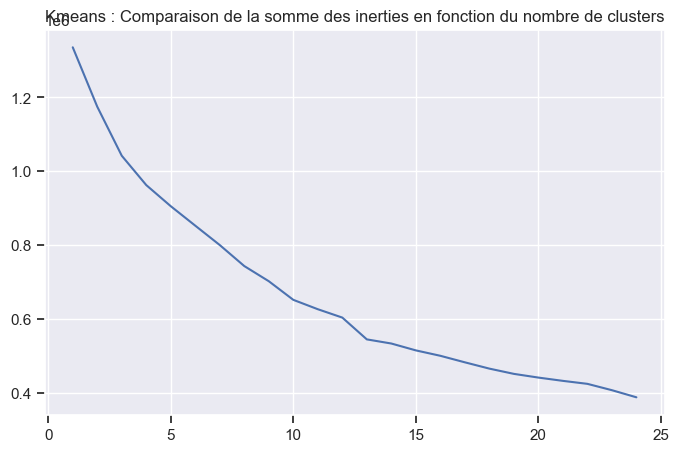

In [30]:
plt.figure(figsize=(8,5))
plt.title('Kmeans : Comparaison de la somme des inerties en fonction du nombre de clusters')
sns.lineplot(list(inertia.keys()),
             list(inertia.values())
            )


In [31]:
inertia = {}
dict_kmeans = {}

nb_boucles=3
max_clusters = 25

for k in range(1,nb_boucles+1):
    print('Boucle ',k)
    for i in range(1,max_clusters+1):
        kmeans = KMeans(n_clusters=i,
                       verbose=1,
                       #n_jobs=-1
                       ).fit(X_std)
        inertia[(k,i)] = kmeans.inertia_
        dict_kmeans[k,i] = kmeans

Boucle  1
Initialization complete
Iteration 0, inertia 4791703.499417391.
Iteration 1, inertia 1335585.9999999953.
Converged at iteration 1: strict convergence.
Initialization complete
Iteration 0, inertia 1731915.3378499916.
Iteration 1, inertia 1238541.2427877453.
Iteration 2, inertia 1214790.1494079218.
Iteration 3, inertia 1176046.6768353987.
Iteration 4, inertia 1174888.500422091.
Iteration 5, inertia 1174879.2946354263.
Converged at iteration 5: center shift 6.537486972185619e-06 within tolerance 0.00010000000000000478.
Initialization complete
Iteration 0, inertia 1461463.134037303.
Iteration 1, inertia 1133456.6437718475.
Iteration 2, inertia 1051166.4565247095.
Iteration 3, inertia 1042186.2481754662.
Iteration 4, inertia 1042175.4238084448.
Converged at iteration 4: center shift 1.5107002853691322e-06 within tolerance 0.00010000000000000478.
Initialization complete
Iteration 0, inertia 1201027.1195539755.
Iteration 1, inertia 1018876.6081548312.
Iteration 2, inertia 1002658.71

Iteration 0, inertia 54395.76259037549.
Iteration 1, inertia 37174.94151799836.
Iteration 2, inertia 36469.78704190371.
Iteration 3, inertia 36230.464670257614.
Iteration 4, inertia 36172.54313163688.
Iteration 5, inertia 36142.52864646783.
Iteration 6, inertia 36110.98365678836.
Iteration 7, inertia 36086.97341213866.
Iteration 8, inertia 36083.73783317379.
Iteration 9, inertia 36082.91057178985.
Iteration 10, inertia 36082.575913231616.
Iteration 11, inertia 36082.43687430932.
Iteration 12, inertia 36082.29497331299.
Iteration 13, inertia 36081.98598188341.
Iteration 14, inertia 36081.64277087267.
Iteration 15, inertia 36081.5432666069.
Converged at iteration 15: center shift 1.6484516643236188e-05 within tolerance 3.605966030769255e-05.
Initialization complete
Iteration 0, inertia 51442.484579713186.
Iteration 1, inertia 35592.42109391393.
Iteration 2, inertia 34987.78549092678.
Iteration 3, inertia 34774.043197479914.
Iteration 4, inertia 34618.386410444065.
Iteration 5, inertia 34

Iteration 0, inertia 49571.244838765764.
Iteration 1, inertia 33857.024438760556.
Iteration 2, inertia 32482.577752810175.
Iteration 3, inertia 31973.534595159435.
Iteration 4, inertia 31755.66020400391.
Iteration 5, inertia 31508.659737855567.
Iteration 6, inertia 31198.338821078614.
Iteration 7, inertia 30838.83491986686.
Iteration 8, inertia 30667.82146353678.
Iteration 9, inertia 30381.11649460908.
Iteration 10, inertia 30106.061516120277.
Iteration 11, inertia 29971.677510927442.
Iteration 12, inertia 29962.53599310407.
Iteration 13, inertia 29955.541476166618.
Iteration 14, inertia 29943.98496212732.
Iteration 15, inertia 29941.558090023987.
Iteration 16, inertia 29940.746562887165.
Iteration 17, inertia 29940.55163428188.
Iteration 18, inertia 29940.40570482332.
Iteration 19, inertia 29940.35933931968.
Iteration 20, inertia 29940.32911982026.
Converged at iteration 20: center shift 3.249503824876272e-05 within tolerance 3.605966030769255e-05.
Initialization complete
Iteration 0,

Iteration 0, inertia 73651.5312496192.
Iteration 1, inertia 50070.287229687456.
Iteration 2, inertia 49305.678456905356.
Iteration 3, inertia 49109.77759934149.
Iteration 4, inertia 48944.637102145454.
Iteration 5, inertia 48865.81359249083.
Iteration 6, inertia 48835.37589980018.
Iteration 7, inertia 48822.803439154784.
Iteration 8, inertia 48817.823951197905.
Iteration 9, inertia 48814.215123346745.
Iteration 10, inertia 48811.87093350178.
Iteration 11, inertia 48810.65912968383.
Iteration 12, inertia 48807.79453611134.
Iteration 13, inertia 48803.457251733445.
Iteration 14, inertia 48800.578059687294.
Iteration 15, inertia 48798.78350960177.
Iteration 16, inertia 48798.18043035808.
Iteration 17, inertia 48797.99923412284.
Converged at iteration 17: strict convergence.
Initialization complete
Iteration 0, inertia 65570.3187610987.
Iteration 1, inertia 48283.668617035306.
Iteration 2, inertia 46387.84940414285.
Iteration 3, inertia 45624.794169194334.
Iteration 4, inertia 45252.323626

Iteration 0, inertia 48739.5345115713.
Iteration 1, inertia 33603.45249295275.
Iteration 2, inertia 32702.653636989526.
Iteration 3, inertia 32430.070453546512.
Iteration 4, inertia 32371.03237867004.
Iteration 5, inertia 32338.921140043683.
Iteration 6, inertia 32265.21417173355.
Iteration 7, inertia 32095.195210593625.
Iteration 8, inertia 31951.152962478023.
Iteration 9, inertia 31922.922607876404.
Iteration 10, inertia 31914.060159862172.
Iteration 11, inertia 31912.589586121532.
Iteration 12, inertia 31911.57743016278.
Iteration 13, inertia 31911.150828198555.
Iteration 14, inertia 31910.934108574034.
Iteration 15, inertia 31910.760354887374.
Iteration 16, inertia 31910.4138141968.
Iteration 17, inertia 31910.350884798416.
Converged at iteration 17: strict convergence.
Initialization complete
Iteration 0, inertia 48656.41039456867.
Iteration 1, inertia 33959.310624687576.
Iteration 2, inertia 32715.257181660094.
Iteration 3, inertia 32339.01111591977.
Iteration 4, inertia 32146.43

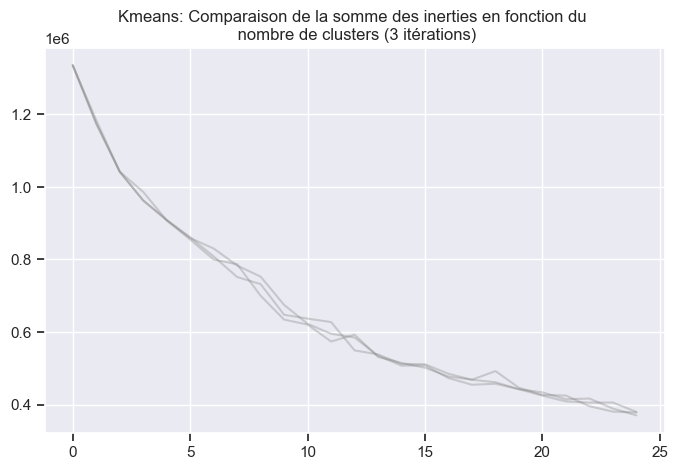

In [32]:
chaine = 'Kmeans: Comparaison de la somme des inerties en fonction du \n nombre de clusters (' + str(nb_boucles) + ' itérations)'
plt.figure(figsize=(8,5))
plt.title(chaine)
for i in range(0,nb_boucles):
    index_plot = [cluster+i*(max_clusters) for cluster in list(range(0,max_clusters))][0:max_clusters]
    sous_liste = [list(inertia.values())[index] for index in index_plot]
    sns.lineplot(list(range(0,max_clusters)),
                 sous_liste, alpha=1/nb_boucles, color='grey')

### coefficient de silhouette

In [ ]:
silhouettes_kmeans = {}
max_clusters = 15
for i in range(2,max_clusters):
    sil_var = silhouette_score(
                                X = X_std,
                                labels= list(dict_kmeans[(1,i)].labels_))
    print(sil_var)
    #print(dict_kmeans[(1,i)].labels_)
    silhouettes_kmeans[i] = sil_var

In [ ]:
plt.figure(figsize=(8,6)),
plt.title('Coefficient de silhouette moyen en fonction du nombre de clusters (kmeans)')
sns.scatterplot(x = list(silhouettes_kmeans.keys()),
               y = list(silhouettes_kmeans.values()))
plt.show()

In [ ]:
for key, value in silhouettes_kmeans.items():
    if value == max(silhouettes_kmeans.values()):
        print('le coefficient de silhouette est maximal pour {} clusters (score = {})'.format(key, value))
        nb_clusters = key

In [36]:
nb_clusters

3

### Model

In [37]:
kmeans = KMeans(n_clusters=3, 
                verbose=1, 
                random_state=0,
               #n_jobs=-1
               ).fit(X_std)

Initialization complete
Iteration 0, inertia 1274651.5556744894.
Iteration 1, inertia 1052565.5897091487.
Iteration 2, inertia 1042313.8243609049.
Iteration 3, inertia 1042185.6982848214.
Iteration 4, inertia 1042176.6114687118.
Converged at iteration 4: center shift 2.5488768164520895e-05 within tolerance 0.00010000000000000478.


In [38]:
kmeans.labels_

array([2, 0, 2, ..., 1, 1, 0])

In [39]:
##wcss stands for within cluster sum of squares


#wcss={}

#for k in range(2,15):
#    km = KMeans(n_clusters=k, init='k-means++', max_iter=1000 , random_state=20)
#    km = km.fit(X)
#    wcss[k] = silhouette_score(X, km.labels_)
    
##Plot graph for the wcss values and the number of clusters

#sns.pointplot(x=list(wcss.keys()), y=list(wcss.values()))
#plt.xlabel('Number of clusters K')
#plt.ylabel('Sum of square distances')
#plt.title('Elbow method for optimal K')
#plt.show()

In [40]:
# score de silhouette
#  sklearn.metrics.silhouette_score(X, labels, *, metric='euclidean', sample_size=None, random_state=None, **kwds)[source]

## T-SNE

In [41]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=0)

In [42]:
tsne_result = tsne.fit_transform(X_std)

In [43]:
tsne_result.shape

(95399, 2)

<AxesSubplot:title={'center':'Représentation de la séparation des données du DBSCAN via T-SNE'}>

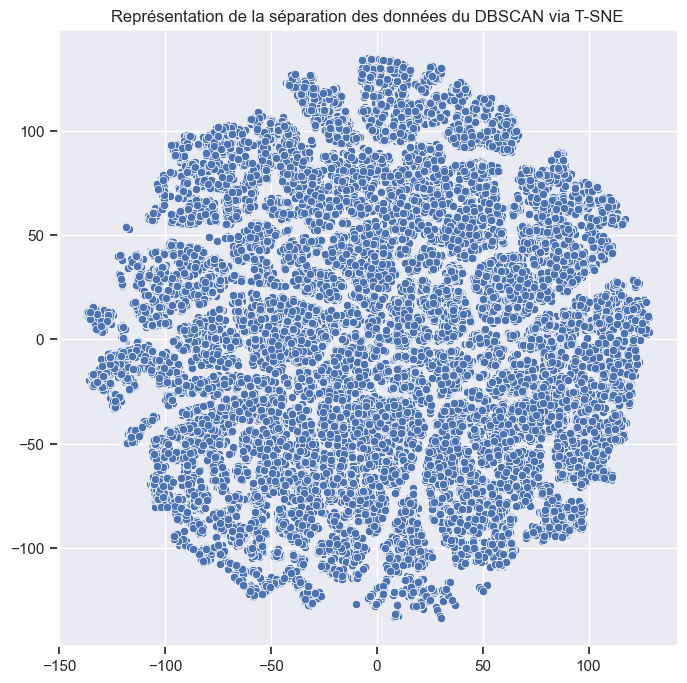

In [44]:
# Représentation via T-SNE
plt.figure(figsize=(8,8))
plt.title('Représentation de la séparation des données du DBSCAN via T-SNE')
sns.scatterplot(tsne_result[:,0], tsne_result[:,1])

# DBscan

In [45]:
dbs = DBSCAN(eps = 1, 
             min_samples=5,
               n_jobs=-1
            ).fit(X_std.copy())

In [46]:
dbs.labels_

array([ 0,  1,  2, ...,  3, -1,  1], dtype=int64)

<AxesSubplot:title={'center':'Représentation de la séparation des données du DBSCAN via T-SNE'}>

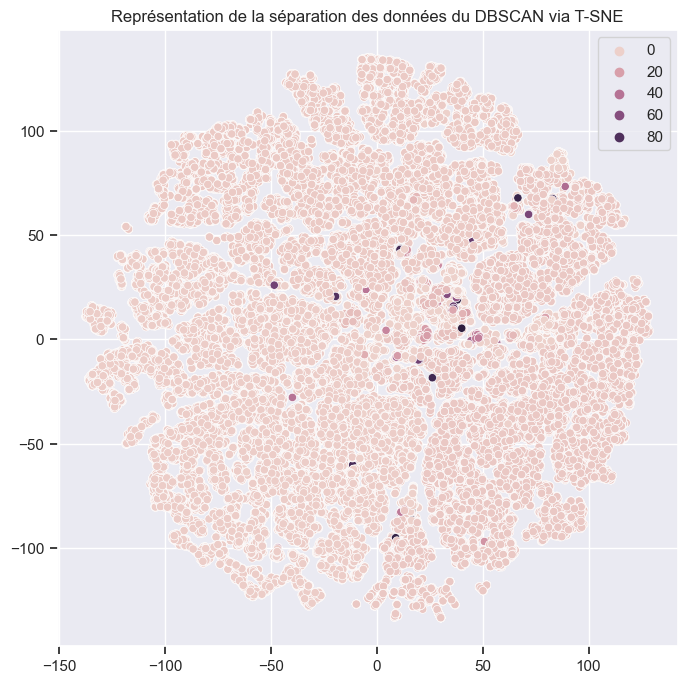

In [47]:
# Représentation via T-SNE
plt.figure(figsize=(8,8))
plt.title('Représentation de la séparation des données du DBSCAN via T-SNE')
sns.scatterplot(tsne_result[:,0], tsne_result[:,1], dbs.labels_)

In [48]:
# https://medium.com/@mohantysandip/a-step-by-step-approach-to-solve-dbscan-algorithms-by-tuning-its-hyper-parameters-93e693a91289
# silhouette to eps distance

# silhouette score gives the avg value for all the samples.
# this gives a perspective into the density and separation of the formed clusters

#range_eps = np.arange(0.1, 1.1, 0.1)
range_eps = np.arange(1, 10, 1)
range_eps

array([1, 2, 3, 4, 5, 6, 7, 8, 9])

In [49]:
dict = {
    "eps_value" :[]
    ,"silhouette_avg" :[]
    }

for i in range_eps:
    #print("eps value is " +str(i))
    db= DBSCAN(eps=i, min_samples=5, n_jobs=-1).fit(X_std)
    core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
    core_samples_mask[db.core_sample_indices_] = True
    labels = db.labels_
    #print(set(labels))
    silhouette_avg = silhouette_score(X_std, labels)
    dict["eps_value"].append(i)
    dict["silhouette_avg"].append(silhouette_avg)
    #print("For eps value = "+str(i), labels,
    #      "The average silhouette_score is : ", silhouette_avg)

eps_df = pd.DataFrame.from_dict(dict)
eps_df.sort_values(by="silhouette_avg", ascending=False)

MemoryError: 

In [ ]:
eps_max_silhouette = float(eps_df.sort_values(by="silhouette_avg", ascending=False).head(1)['eps_value'])
eps_max_silhouette

In [ ]:
# find the 'min_samples' hyper parameter through right cluster formation method

min_samples = np.arange(1, 11, 1)
min_samples

In [ ]:
dict2 = {
    "min_sample_value" :[]
    ,"nb_clusters" :[]
    }

for i in min_samples:
    db= DBSCAN(eps=eps_max_silhouette, min_samples=i, n_jobs=-1).fit(X_enc)
    core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
    core_samples_mask[db.core_sample_indices_] = True
    # Ignoring the label '-1' as its for the outliers
    labels = set([label for label in db.labels_ if label >=0])
    dict2["min_sample_value"].append(i)
    dict2["nb_clusters"].append(str(len(set(labels))))
    #print("For eps value = "+str(i), labels,
    #      "The average silhouette_score is : ", silhouette_avg)

min_samples_df = pd.DataFrame.from_dict(dict2)
min_samples_df.sort_values(by="nb_clusters", ascending=False) 

In [ ]:
### compute DBSCAN with new values :
dbs_2 = DBSCAN(eps= 2, 
             min_samples= 7,
               n_jobs= -1
            ).fit(X_enc.copy())
dbs_2.labels_

In [ ]:
# Représentation via T-SNE
plt.figure(figsize=(8,8))
plt.title('Représentation de la séparation des données du DBSCAN via T-SNE')
sns.scatterplot(tsne_result[:,0], tsne_result[:,1], dbs_2.labels_)

## SMOTE-NC

In [ ]:
# https://medium.com/analytics-vidhya/smote-nc-in-ml-categorization-models-fo-imbalanced-datasets-8adbdcf08c25

### Clustering hiérarchique

In [ ]:
nb_clusters_agg = nb_clusters

In [ ]:
cah = AgglomerativeClustering(n_clusters = nb_clusters_agg
                             ).fit(X.copy())


In [ ]:
graph = pd.DataFrame(data = [T[:,0], T[:,1], dict_kmeans[(1,11)].labels_]).T
graph.columns = ['X', 'Y', 'label_kmeans']

In [ ]:
graph['x_pca'] = x_show
graph['y_pca'] = y_show
graph['z_pca'] = z_show

In [ ]:
graph

In [ ]:
plt.figure(figsize=(10,10))
plt.title('Représentation de la séparation des données du CAH via T-SNE')
sns.scatterplot(graph['X'], 
                graph['Y'], 
                hue = cah.labels_, 
                legend='full',
               palette=sns.color_palette("hls",nb_clusters_agg))
plt.legend(loc='upper left', labels=graph['label_kmeans'].unique())
plt.show()

In [ ]:
## ne pas utiliser PCA (permet de voir cassure) => focus TSNE (x y z)
## dbscan sur 3
# visualisation : tsne + labels/couleurs, scatterplot
# /!\ scaling / encoding données : dans la préparation des données, modelisation = modeles uniquement

In [ ]:
# ajouter features
# chercher meilleur parametrage 
# pour kmeans et pour dbscan
# /!\ responsable pédagogique